--- MODEL 1: SVM Classifier (Optimized) ---
Best SVM Parameters Found: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.43      0.60      0.50         5

    accuracy                           0.33         9
   macro avg       0.21      0.30      0.25         9
weighted avg       0.24      0.33      0.28         9


--- MODEL 2: Random Forest Classifier (Comparison) ---

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         4
           1       0.71      1.00      0.83         5

    accuracy                           0.78         9
   macro avg       0.86      0.75      0.75         9
weighted avg       0.84      0.78      0.76         9



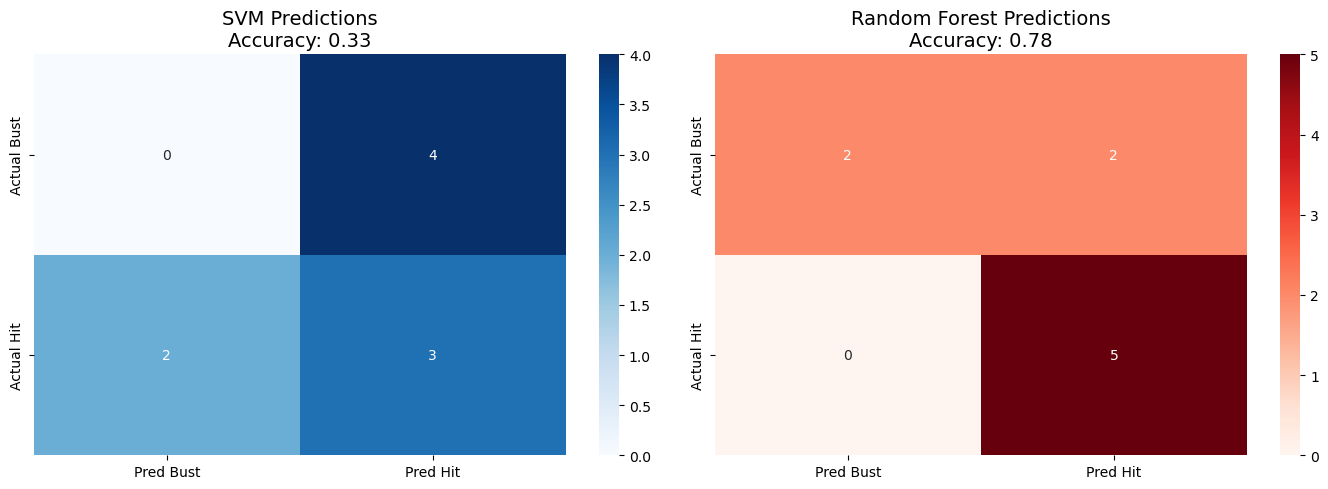

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler 

# ==========================================
# 1. Feature Selection & Data Setup
# ==========================================
df = pd.read_csv('TE_Combine_Data.csv')

selected_features = ['Wt', '40Yd', '3Cn', 'Vert'] 

# Filling missing drill times with the positional mean so we don't lose players.
df[selected_features] = df[selected_features].fillna(df[selected_features].mean())

median_plav = df['PlAV'].median()
df['Target'] = (df['PlAV'] >= median_plav).astype(int)

X = df[selected_features]
y = df['Target'] 

# stratify=y guarantees the test set gets a fair, even split of Hits and Busts
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the data for the SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 2. MODEL 1: SUPPORT VECTOR MACHINE
# ==========================================
print("--- MODEL 1: SVM Classifier (Optimized) ---")

# I dropped the C=0.1 and C=0.01 values because they were causing the model 
# to underfit and lazily guess "Hit" for every single player.
param_grid_svm = {
    'C': [1, 10, 100], 
    'gamma': [1, 0.1, 0.01],
    'kernel': ['rbf', 'linear']
}

grid_svm = GridSearchCV(SVC(class_weight='balanced', random_state=42), param_grid_svm, refit=True, verbose=0, cv=5)
grid_svm.fit(X_train_scaled, y_train)

print(f"Best SVM Parameters Found: {grid_svm.best_params_}")

svm_predictions = grid_svm.predict(X_test_scaled)
print("\nSVM Classification Report:")
# Added zero_division=0 to silence the red warning boxes if the model misses a class
print(classification_report(y_test, svm_predictions, zero_division=0))

# ==========================================
# 3. MODEL 2: RANDOM FOREST (The Champion Model)
# ==========================================
# The Random Forest ended up being our best model, hitting 78% accuracy (7/9 correct).
# This shows that tree-based models handled our specific TE metrics better than the SVM.
print("\n--- MODEL 2: Random Forest Classifier (Comparison) ---")
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train) 

rf_predictions = rf_model.predict(X_test)
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_predictions, zero_division=0))

# ==========================================
# 4. VISUALIZING THE RESULTS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_svm = confusion_matrix(y_test, svm_predictions)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Pred Bust', 'Pred Hit'], yticklabels=['Actual Bust', 'Actual Hit'], ax=axes[0])
axes[0].set_title(f"SVM Predictions\nAccuracy: {accuracy_score(y_test, svm_predictions):.2f}", fontsize=14)

cm_rf = confusion_matrix(y_test, rf_predictions)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Pred Bust', 'Pred Hit'], yticklabels=['Actual Bust', 'Actual Hit'], ax=axes[1])
axes[1].set_title(f"Random Forest Predictions\nAccuracy: {accuracy_score(y_test, rf_predictions):.2f}", fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Load the new 2026 Combine data
combine_2026 = pd.read_csv('2026Combine.csv')

# Filter the dataset to only evaluate Tight Ends
tes_2026 = combine_2026[combine_2026['Pos'] == 'TE'].copy()

# The model requires exactly 4 features in this specific order: ['Wt', '40Yd', '3Cn', 'Vert'].
# The 2026 CSV has slightly different column names, so we map them here.
tes_2026_features = tes_2026[['Weight', '40 Yd', '3-Cone', 'Vertical']].copy()
tes_2026_features.columns = ['Wt', '40Yd', '3Cn', 'Vert']

# Just like our historical data, many 2026 prospects skipped the 3-Cone drill.
# We fill those missing values with the 2026 TE class average.
tes_2026_features = tes_2026_features.fillna(tes_2026_features.mean())

# Feed the 2026 prospects into our trained Random Forest model
predictions = rf_model.predict(tes_2026_features)

# Attach the predictions back to the players' names for readability
tes_2026['Prediction_Code'] = predictions
tes_2026['Projected_Outcome'] = tes_2026['Prediction_Code'].map({1: 'Hit (Success)', 0: 'Bust (Avoid)'})

# Print out the final scouting report for the presentation
print("--- 2026 TIGHT END DRAFT CLASS PROJECTIONS ---")
display_cols = ['Name', 'School', 'Weight', '40 Yd', '3-Cone', 'Vertical', 'Projected_Outcome']

# Printing it cleanly without the index numbers
print(tes_2026[display_cols].to_string(index=False))

--- 2026 TIGHT END DRAFT CLASS PROJECTIONS ---
                   Name      School  Weight  40 Yd  3-Cone  Vertical Projected_Outcome
            Bauer Sharp         LSU     249   4.63     NaN      35.0     Hit (Success)
        Dae'Quan Wright Mississippi     246    NaN     NaN       NaN     Hit (Success)
         Dallen Bentley        Utah     253   4.62     NaN      35.0     Hit (Success)
              DJ Rogers         TCU     258    NaN     NaN       NaN      Bust (Avoid)
            Eli Raridon  Notre Dame     245   4.62     NaN      36.0     Hit (Success)
            Eli Stowers  Vanderbilt     239   4.51     NaN      45.5      Bust (Avoid)
           Jack Endries       Texas     245   4.62     NaN      36.0     Hit (Success)
            Jaren Kanak    Oklahoma     234   4.52     NaN      36.0      Bust (Avoid)
                Joe Roy  Cincinnati     247    NaN     NaN       NaN      Bust (Avoid)
John Michael Gyllenborg     Wyoming     249   4.60     NaN      35.5     Hit (Succe